# RFM Segmenting using Unidentified Customer Information from Small Business Ecommerce Sales

In [1]:
# import necessary modules for analysis
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
# preset matplotlib parameters for better plots
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300

## Defining Functions
Here, we will define functions that we will use to segment our sample or populaiton
based on RFM analysis

In [3]:
# we tried to split into even quintiles, but so
# many customers had only one order that it was
# impossible to break into even groups. So instead
# we broke into sections based on how many orders the
# customer has made
def frequency_score(x):
    if x == 1:
        return 1
    elif x == 2:
        return 2
    # if it's 3 or 4 orders
    elif x <= 4:
        return 3
    # if it's 5-9 orders
    elif x <= 9:
        return 4
    # if it's 10 orders or more
    else:
        return 5

In [4]:
def create_fm_segment(df, segment="Dormant", 
                      recency_column="recency_score",
                      fm_column="fm_score"):
    """
    Breaks the dataframe based on the segment types suggested by Shopify
    """
    temp_df = df.copy()

    temp_df[recency_column] = pd.to_numeric(temp_df[recency_column])
    temp_df[fm_column] = pd.to_numeric(temp_df[fm_column])

    if segment == "Dormant":
        filtered_df = temp_df[
            (temp_df[recency_column] <= 2) &
            (temp_df[fm_column] <= 2)
        ]

    elif segment == "At Risk":
        filtered_df = temp_df[
            (temp_df[recency_column] <= 2) &
            (temp_df[fm_column] > 2) &
            (temp_df[fm_column] <= 4)
        ]

    elif segment == "Previously Loyal":
        filtered_df = temp_df[
            (temp_df[recency_column] <= 2) &
            (temp_df[fm_column] > 4)
        ]

    elif segment == "Almost Lost":
        filtered_df = temp_df[
            (temp_df[recency_column] > 2) &
            (temp_df[recency_column] <= 3) &
            (temp_df[fm_column] <= 2)
        ]

    elif segment == "Needs Attention":
        filtered_df = temp_df[
            (temp_df[recency_column] > 2) &
            (temp_df[recency_column] <= 3) &
            (temp_df[fm_column] > 2) &
            (temp_df[fm_column] <= 3)
        ]

    elif segment == "Loyal":
        filtered_df = temp_df[
            (temp_df[recency_column] > 2) &
            (temp_df[recency_column] <= 4) &
            (temp_df[fm_column] > 3)
        ]

    elif segment == "Promising":
        filtered_df = temp_df[
            (temp_df[recency_column] > 3) &
            (temp_df[recency_column] <= 4) &
            (temp_df[fm_column] <= 1)
        ]

    elif segment == "New":
        filtered_df = temp_df[
            (temp_df[recency_column] > 4) &
            (temp_df[fm_column] <= 1)
        ]

    elif segment == "Active":
        filtered_df = temp_df[
            (temp_df[recency_column] > 3) &
            (temp_df[fm_column] > 1) &
            (temp_df[fm_column] <= 3)
        ]

    elif segment == "Champions":
        filtered_df = temp_df[
            (temp_df[recency_column] > 4) &
            (temp_df[fm_column] > 3)
        ]

    else:
        raise ValueError(f"Segment '{segment}' is not recognized.")

    return filtered_df

In [5]:
def size_group(segment_df, total_customers) -> dict:
    """
    return statistics about the segment compared to the total
    """
    # how many customers are in the segment
    segment_count = len(segment_df)
    # percentage based on total customers
    segment_percentage = segment_count / total_customers * 100
    dictionary = {
        "count": segment_count,
        "percentage": segment_percentage
    }
    return(dictionary)

In [6]:
# import the data as a dataframe, then assign datetime object
ecomm = pd.read_csv("unidentified_ecom_data.csv")
ecomm["datetime"] = pd.to_datetime(ecomm["order_date_dt"], format = "mixed")
# display the top 10 rows for show
ecomm.head(10)

,subtotal,order_date_dt,order_total_revenue,zip_code,unique_customer_id,datetime
0,40.0,2024-08-17,24.0,NaN,1,2024-08-17
1,75.0,2024-08-17,40.0,NaN,2,2024-08-17
2,300.0,2024-08-14,200.0,80027.0,3,2024-08-14
3,40.0,2024-08-02,24.0,89122.0,4,2024-08-02
4,150.0,2024-08-02,100.0,81657.0,5,2024-08-02
5,150.0,2024-08-01,100.0,NaN,6,2024-08-01
6,80.0,2024-08-01,56.0,NaN,7,2024-08-01
7,80.0,2024-08-01,56.0,NaN,7,2024-08-01
8,80.0,2024-08-01,56.0,NaN,7,2024-08-01
9,80.0,2024-08-01,56.0,NaN,7,2024-08-01


## Total Sales Across Time
### Brief Summary Statistics of the Dataset
### Including time period, number of customers, and number of orders

In [7]:
# display the first order and the last order
first_order = ecomm["datetime"].min()
latest_order = ecomm["datetime"].max()
time_diff = (latest_order - first_order)
days_total = time_diff.days

# floor division operator; only take full years
years = days_total // 365
# modulus operator, take what's left over in days
# divide by 30
months = (days_total % 365) // 30
days = (days_total % 365) % 30

print(f"The first order in this dataset was placed {first_order}")
print("")
print(f"The latest order in this dataset was placed {latest_order}")
print(f"""
Meaning this dataset spans approx. 
{years} years, {months} months, and {days} days of sales data.
""")
print("This is the sample 'period'")

The first order in this dataset was placed 2021-11-26 00:00:00

The latest order in this dataset was placed 2026-04-18 00:00:00

Meaning this dataset spans approx. 
4 years, 4 months, and 24 days of sales data.

This is the sample 'period'


In [46]:
# quick summary statistics
total_revenue = round((ecomm["order_total_revenue"].sum()), 2)
number_orders = len(ecomm)
average_order_value = round(ecomm["order_total_revenue"].mean(), 2)
median_order_value = round(ecomm["order_total_revenue"].median(), 1)
aov_sd = round(ecomm["order_total_revenue"].std(), 2)

print("Summary statistics for small health/wellness CPG ecommerce business:")
print(f"The total revenue in the period is ${total_revenue}")
print(f"There is a total of {number_orders} orders")
print(f"The average order value is ${average_order_value} (sd = ${aov_sd}), including shipping and taxes")
print(f"The median order value is ${median_order_value}")

Summary statistics for small health/wellness CPG ecommerce business:
The total revenue in the period is $135022.53
There is a total of 1973 orders
The average order value is $68.44 (sd = $51.55), including shipping and taxes
The median order value is $50.0


In [9]:
# as a quick test, let's greate a groupby by date to see daily
# revenue mapped over time
daily_purchase = ecomm.groupby("datetime")["order_total_revenue"].sum().reset_index()
# display the top 4 of this new grouping
daily_purchase.head(5)

,datetime,order_total_revenue
0,2021-11-26,12.99
1,2021-12-06,81.99
2,2021-12-07,722.91
3,2021-12-11,1610.00
4,2021-12-12,300.00


In [10]:
average_daily_revenue = daily_purchase["order_total_revenue"].mean().round(2)
med_daily_revenue = daily_purchase["order_total_revenue"].median()
print(f"""
The average daily revenue for this small ecomm business is:
{average_daily_revenue}
With a median daily revenue of:
{med_daily_revenue}
""")


The average daily revenue for this small ecomm business is:
157.55
With a median daily revenue of:
92.4



In [40]:
customer_count1 = len(ecomm["unique_customer_id"].unique())
print(f"These orders were placed by a total of {customer_count1} customers")

These orders were placed by a total of 843 customers


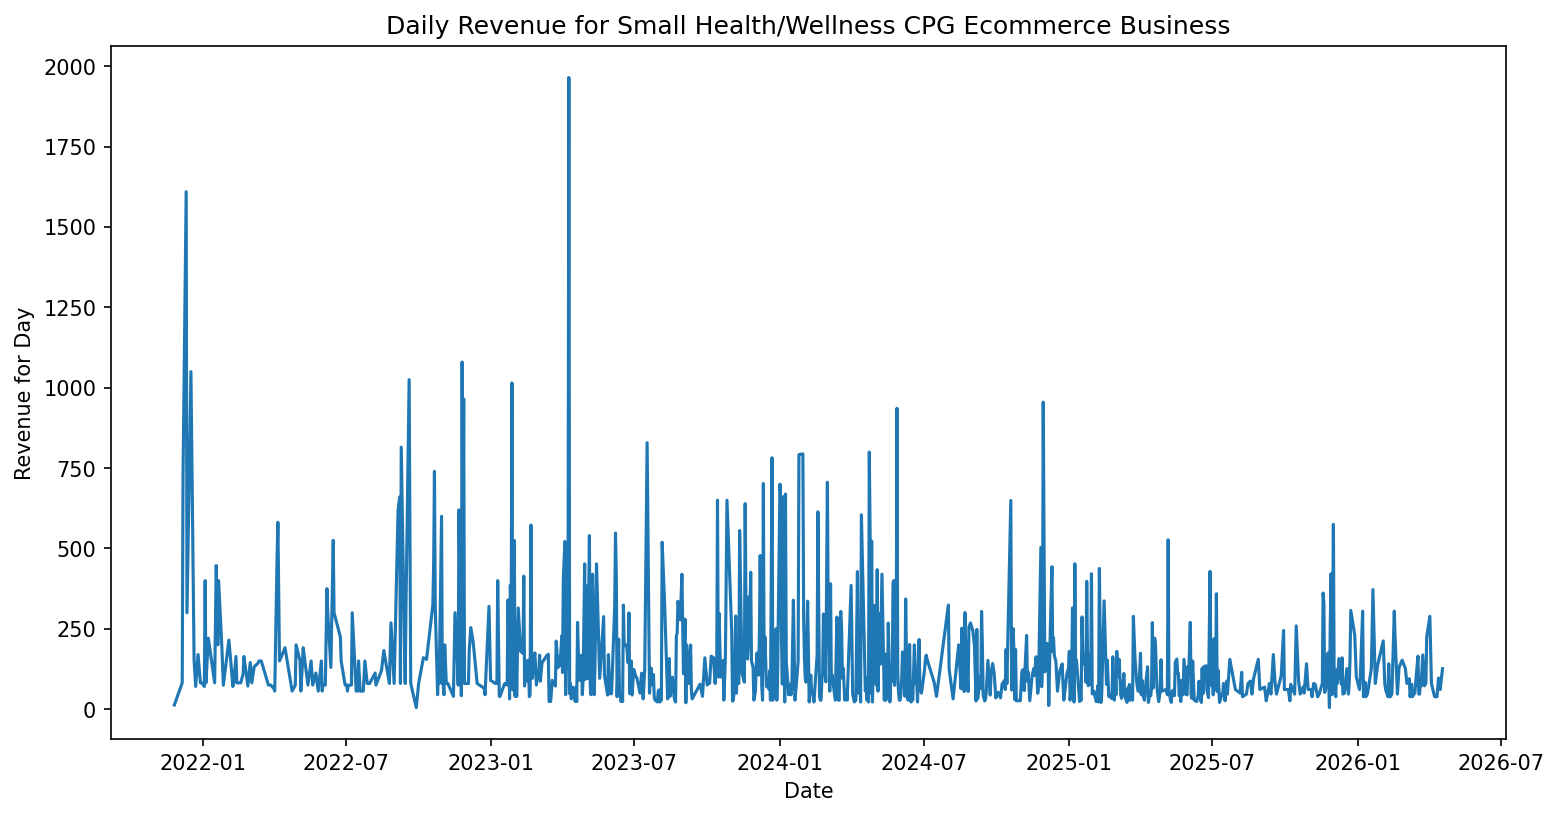

In [53]:
# plot the data above
plt.plot(daily_purchase["datetime"], 
         daily_purchase["order_total_revenue"])
plt.xlabel("Date")
plt.ylabel("Revenue for Day")
plt.title("Daily Revenue for Small Health/Wellness CPG Ecommerce Business")
plt.savefig("daily_revenue.png")
plt.show()

## Sales Data By Customer

In [12]:
# next we will figure out average spend for customer in a lifetime
person_purchase = ecomm.groupby("unique_customer_id")["order_total_revenue"].sum().reset_index()

average_purchaser = round((person_purchase["order_total_revenue"].mean()), 2)
average_purchaser_dev = round((person_purchase["order_total_revenue"].std()), 2)
highest_purchaser = person_purchase["order_total_revenue"].max()
lowest_purchaser = person_purchase["order_total_revenue"].min()
print(f"""
The average customer spent ${average_purchaser} 
(SD = {average_purchaser_dev}) in the period.
""")
print(f"The highest spending customer spent ${highest_purchaser} in the period.")
print(f"The lowest spending customer spent ${lowest_purchaser} in the period.")


The average customer spent $160.17 
(SD = 332.14) in the period.

The highest spending customer spent $3670.9 in the period.
The lowest spending customer spent $11.6 in the period.


## Prepare Monetary and Frequency Data

In [13]:
# here, let's do some equations to build the dataset we
# can runt the RFM off of. First, we want to group by unique
# customer id. Then we want their total revenue.
# we also want a list of all of the dates that each customer
# purchased so we can do recency and frequency. 
customer_summary = (
    ecomm.groupby("unique_customer_id")
      .agg({
          "order_total_revenue": "sum",
          "datetime": list
      })
      .reset_index()
)

customer_summary["num_orders"] = customer_summary["datetime"].apply(len)
customer_summary["latest_order"] = customer_summary["datetime"].apply(max)

## Prepare Recency Data

In [14]:
# establish todays date to get a recency number
# smaller recency number = more recent (less days since last purchase)
today = pd.Timestamp.today()
customer_summary["days_last_purchase"] = (
    today - customer_summary["latest_order"]
).dt.days


In [15]:
customer_summary.head()

,unique_customer_id,order_total_revenue,datetime,num_orders,latest_order,days_last_purchase
0,1,144.00,"[2024-08-17 00:00:00, 2024-05-27 00:00:00, 202...",3,2024-08-29,611
1,2,136.25,"[2024-08-17 00:00:00, 2024-07-17 00:00:00, 202...",3,2024-08-17,623
2,3,760.80,"[2024-08-14 00:00:00, 2024-06-25 00:00:00, 202...",6,2025-11-28,155
3,4,440.00,"[2024-08-02 00:00:00, 2024-07-02 00:00:00, 202...",19,2025-05-19,348
4,5,422.00,"[2024-08-02 00:00:00, 2024-03-21 00:00:00, 202...",4,2024-08-02,638


## Assign Recency Score

In [16]:
# here, we will break the data into quintiles based on the
# days since the last purchase and assign to `recency_score`
customer_summary["recency_score"] = pd.qcut(
    customer_summary["days_last_purchase"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

## Assign Frequency Score

In [17]:
customer_summary["frequency_score"] = customer_summary["num_orders"].apply(frequency_score)

## Assign Monetary Score

In [18]:
# now we will use a similar function using pandas.qcut to
# break it into quintiles based on total revenue
customer_summary["monetary_score"] = pd.qcut(
    customer_summary["order_total_revenue"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

## Combine to Make RFM Codes

In [19]:
# here we are going to turn the scores into strings then
# combine them to give an RFM code for each participant.
customer_summary["rfm_code"] = (
    customer_summary["recency_score"].astype(str) +
    customer_summary["frequency_score"].astype(str) +
    customer_summary["monetary_score"].astype(str)
)

In [20]:
customer_summary.head(5)

,unique_customer_id,order_total_revenue,datetime,num_orders,latest_order,days_last_purchase,recency_score,frequency_score,monetary_score,rfm_code
0,1,144.00,"[2024-08-17 00:00:00, 2024-05-27 00:00:00, 202...",3,2024-08-29,611,3,3,4,334
1,2,136.25,"[2024-08-17 00:00:00, 2024-07-17 00:00:00, 202...",3,2024-08-17,623,3,3,4,334
2,3,760.80,"[2024-08-14 00:00:00, 2024-06-25 00:00:00, 202...",6,2025-11-28,155,5,4,5,545
3,4,440.00,"[2024-08-02 00:00:00, 2024-07-02 00:00:00, 202...",19,2025-05-19,348,5,5,5,555
4,5,422.00,"[2024-08-02 00:00:00, 2024-03-21 00:00:00, 202...",4,2024-08-02,638,3,3,5,335


In [21]:
# Create combined frequency/monetary score
# where both frequency and monetary are weighted
# equally. Although this does not align with common
# RFM practice, it does allow us to plot in a 2D space
customer_summary["fm_score"] = (
    customer_summary["frequency_score"].astype(int) + 
    customer_summary["monetary_score"].astype(int)) / 2


In [22]:
customer_summary.head(3)

,unique_customer_id,order_total_revenue,datetime,num_orders,latest_order,days_last_purchase,recency_score,frequency_score,monetary_score,rfm_code,fm_score
0,1,144.00,"[2024-08-17 00:00:00, 2024-05-27 00:00:00, 202...",3,2024-08-29,611,3,3,4,334,3.5
1,2,136.25,"[2024-08-17 00:00:00, 2024-07-17 00:00:00, 202...",3,2024-08-17,623,3,3,4,334,3.5
2,3,760.80,"[2024-08-14 00:00:00, 2024-06-25 00:00:00, 202...",6,2025-11-28,155,5,4,5,545,4.5


In [51]:
num_orders_per_customer = round(customer_summary["num_orders"].mean(), 2)
std_num_orders_per_customer = round(customer_summary["num_orders"].std(), 2)
median_orders_per_customer = customer_summary["num_orders"].median()
print(f"""
On average, a customer for this company 
places {num_orders_per_customer} (sd = {std_num_orders_per_customer})orders over their customer lifetime
""")
print(f"The median number of orders per customer is {median_orders_per_customer}")


On average, a customer for this company 
places 2.34 (sd = 4.14)orders over their customer lifetime

The median number of orders per customer is 1.0


In [23]:
# assign segments based on Shopify (2026)
segments = [
    "Dormant",
    "At Risk",
    "Previously Loyal",
    "Almost Lost",
    "Needs Attention",
    "Loyal",
    "Promising",
    "New",
    "Active",
    "Champions"
]

# make a copy for segmenting
full_rfm_df = customer_summary.copy()
# export copy for records
full_rfm_df.to_csv("full_rfm_data.csv")
# calculate total customers as static variable for percentages
total_customers_rfm = len(full_rfm_df)


## Break Up Segments into Separate Dataframes for Targeted Marketing Efforts and
## Create a Dictionary of Segment Data with Segments for Further Analysis

In [31]:
# create the segment_data dictionary
# so that we can extract all of the
# segments based on the recency vs frequency_moneatry compound
segment_data = {}
for segment_name in segments:
    ls = []
    # create a filtered dataframe baseed on the segment parameters
    filtered_df = create_fm_segment(full_rfm_df, segment=segment_name)
    filename = segment_name + "-segment.csv"
    pathname = "segments/" + filename
    # export the dataframe for the segment for easy contact
    filtered_df.to_csv(pathname)
    ls.append(filtered_df)
    extra_data = size_group(filtered_df, total_customers = total_customers_rfm)
    ls.append(extra_data)
    segment_data[segment_name] = ls

    

In [56]:
# Group customers by full rfm score
# so we have data to plot, including revenue
rfm_grid_rfm_full = (
    customer_summary
    .groupby(["rfm_code"])
    .agg(
        customers=("unique_customer_id", "count"),
        revenue=("order_total_revenue", "sum")
    )
    .reset_index()
)

# add column with calculation percent of customers per cohort
rfm_grid_rfm_full["percent_customers"] = (
    rfm_grid_rfm_full["customers"] / rfm_grid_rfm_full["customers"].sum() * 100
)
rfm_grid_rfm_full.to_csv("full_rfm_breakdown_by_code.csv")
rfm_grid_rfm_full.head(5)

,rfm_code,customers,revenue,percent_customers
0,111,7,168.99,0.830368
1,112,31,1479.44,3.677343
2,113,72,5531.47,8.540925
3,114,26,3355.68,3.084223
4,115,8,1851.25,0.948992


In [32]:
# Group customers by recency and fm score
# so we have data to plot, including revenue
rfm_grid_fm = (
    customer_summary
    .groupby(["recency_score", "fm_score"])
    .agg(
        customers=("unique_customer_id", "count"),
        revenue=("order_total_revenue", "sum")
    )
    .reset_index()
)

# add column with calculation percent of customers per cohort
rfm_grid_fm["percent_customers"] = (
    rfm_grid_fm["customers"] / rfm_grid_fm["customers"].sum() * 100
)

In [33]:
# export and visualize the new df

rfm_grid_fm.head(3)

,recency_score,fm_score,customers,revenue,percent_customers
0,5,1.0,15,399.70,1.779359
1,5,1.5,20,938.00,2.372479
2,5,2.0,34,2521.75,4.033215


/var/folders/j7/xmp7jc5j5dv87n7wnjyf62g80000gn/T/ipykernel_74999/2166297985.py:56: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


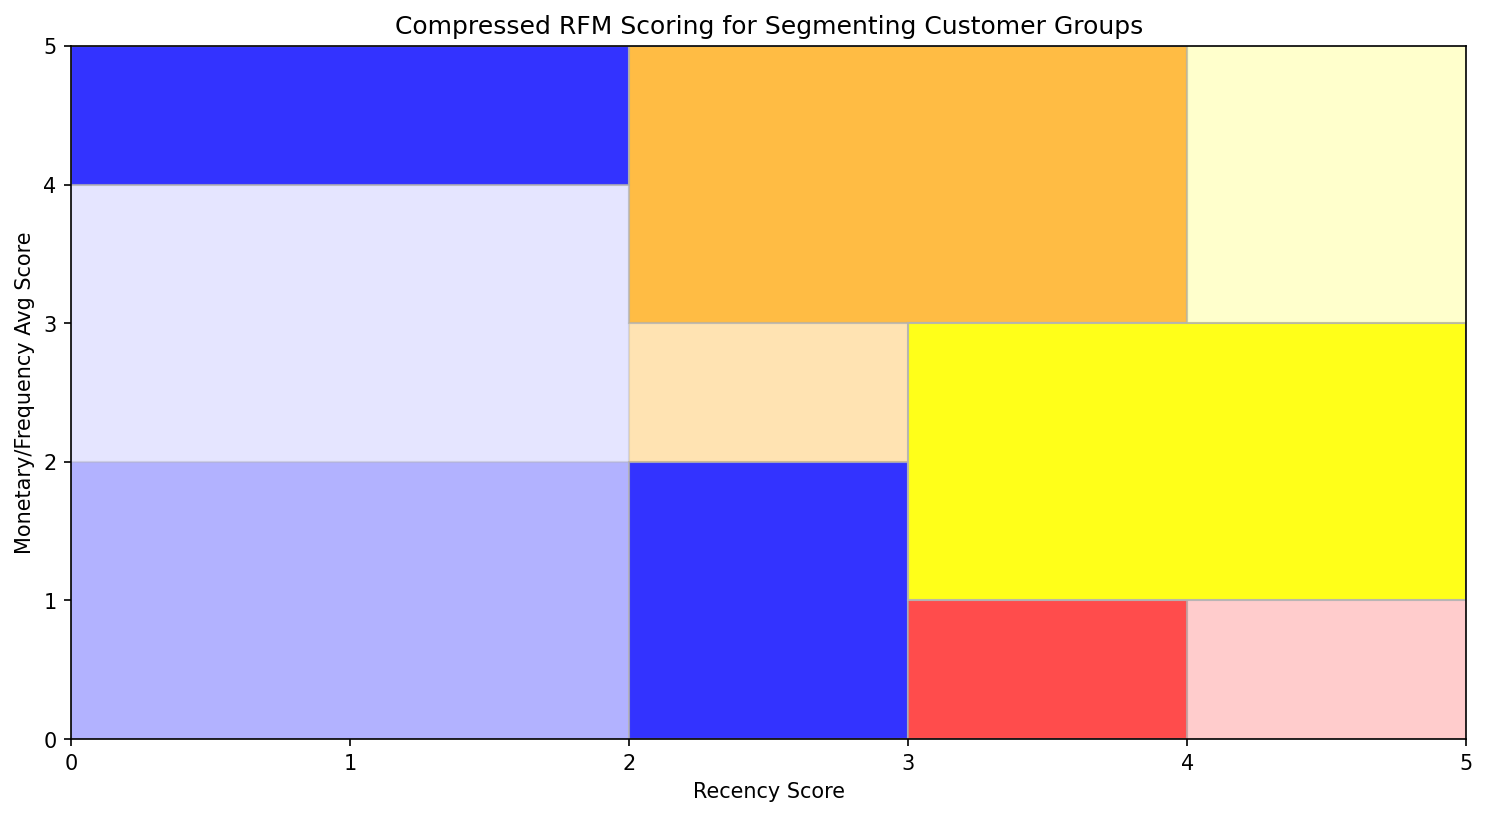

In [27]:
# create the figure
fig, ax = plt.subplots()
ax.set_xlim(0, 5)
ax.set_ylim(0,5)
# Dormancy Box
ax.add_patch(Rectangle(xy=(0,0), 
                       width=2,height=2, facecolor="blue", 
                       edgecolor='0.7', alpha=0.3))
# at risk box
ax.add_patch(Rectangle(xy=(0,2),
                       width=2, height = 2, facecolor = "blue",
                       edgecolor="0.7", alpha = 0.1))
# previously loyal box
ax.add_patch(Rectangle(xy=(0,4),
                       width=2, height = 1, facecolor = "blue",
                       edgecolor="0.7", alpha = 0.8))

# Almost lost box
ax.add_patch(Rectangle(xy=(2,0),
                       width=1, height = 2, facecolor = "blue",
                       edgecolor="0.7", alpha = 0.8))

# needs attention box
ax.add_patch(Rectangle(xy=(2,3),
                       width=2, height = 2, facecolor = "orange",
                       edgecolor="0.7", alpha = 0.1))
# some box
ax.add_patch(Rectangle(xy=(2,2),
                       width=1, height = 1, facecolor = "orange",
                       edgecolor="0.7", alpha = 0.3))
# LOYAL box
ax.add_patch(Rectangle(xy=(2,3),
                       width=2, height = 2, facecolor = "orange",
                       edgecolor="0.7", alpha = 0.7))

# promising box
ax.add_patch(Rectangle(xy=(3,0),
                       width=1, height = 1, facecolor = "red",
                       edgecolor="0.7", alpha = 0.7))
# new box
ax.add_patch(Rectangle(xy=(4,0),
                       width=1, height = 1, facecolor = "red",
                       edgecolor="0.7", alpha = 0.2))
# Active box
ax.add_patch(Rectangle(xy=(3,1),
                       width=2, height = 2, facecolor = "yellow",
                       edgecolor="0.7", alpha = 0.9))
# Champions
ax.add_patch(Rectangle(xy=(4,3),
                       width=1, height = 2, facecolor = "yellow",
                       edgecolor="0.7", alpha = 0.2))

ax.set_xlabel("Recency Score")
ax.set_ylabel("Monetary/Frequency Avg Score")
ax.set_title("Compressed RFM Scoring for Segmenting Customer Groups")
fig.show()

## Segment Charting

/var/folders/j7/xmp7jc5j5dv87n7wnjyf62g80000gn/T/ipykernel_74999/2965160828.py:85: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


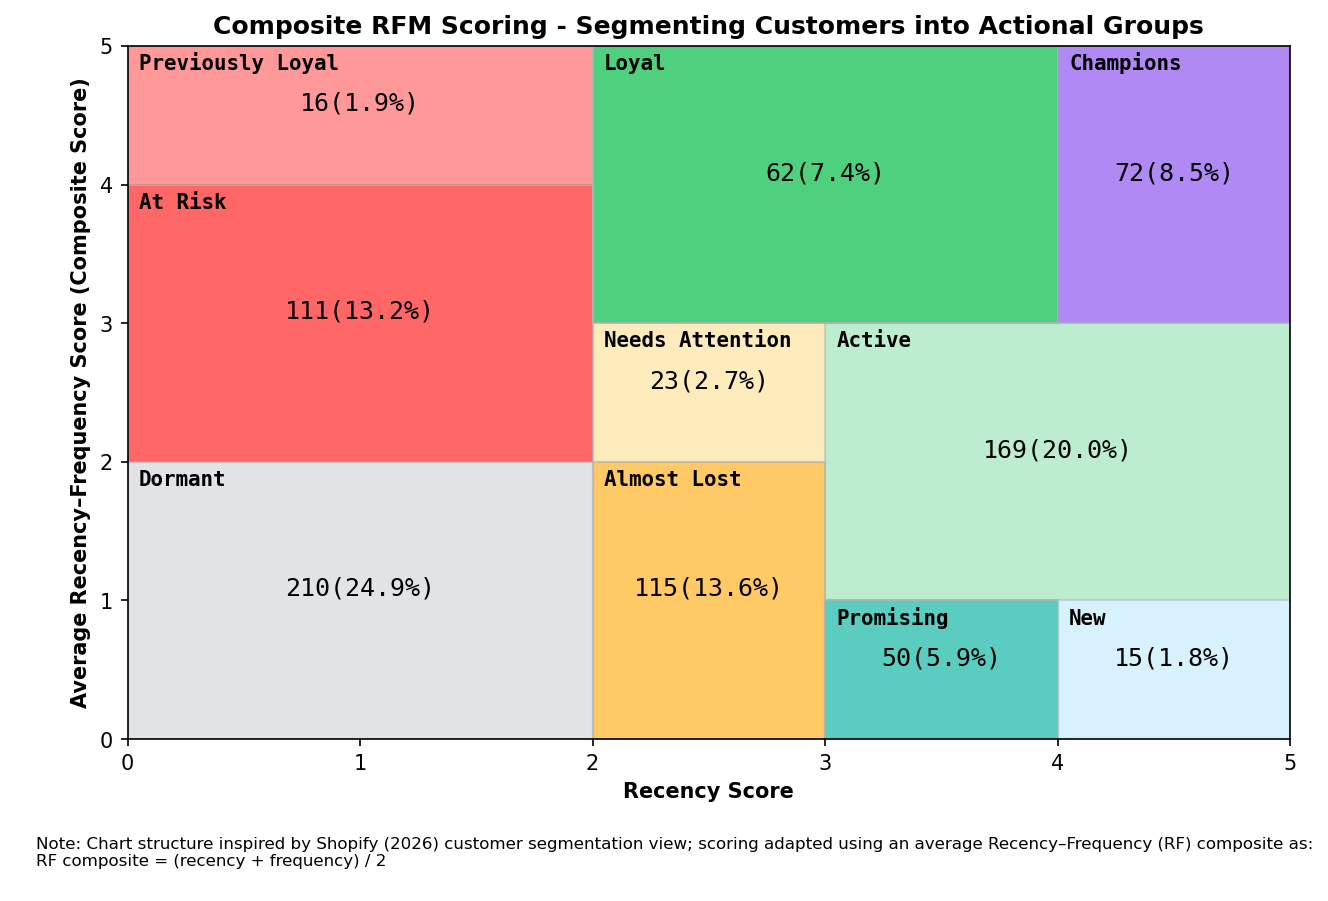

In [34]:
# create the figure that demonstrates the segments
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.set_xlim(0, 5)
ax.set_ylim(0,5)

def add_box(x_start, y_start, width, height, color, alpha, label):
    ax.add_patch(Rectangle(
        xy=(x_start, y_start),
        width=width,
        height=height,
        facecolor=color,
        edgecolor="0.7",
        alpha=alpha
    ))
    # create centerpoints for each box based on existing coordinate info
    center_x = (x_start + (width / 2))
    center_y = (y_start + (height / 2))
    
    # add label box
    ax.text((x_start + 0.05), (y_start + (height - 0.2)), label,
        verticalalignment='bottom', horizontalalignment='left',
        color='black', weight = "bold", fontname = 'monospace')
    # extract customer data from the dictionary of segments
    customer_data = segment_data[label][1]
    customer_count = str(customer_data["count"])
    customer_percentage = str(round(customer_data["percentage"], 1))
    customer_summary_stat = customer_count + "(" + customer_percentage + "%)"
    
    # add customer info box
    ax.text(center_x, center_y, customer_summary_stat,
        verticalalignment='bottom', horizontalalignment='center',
        color='black', fontsize = "large", fontname = "monospace")

    
fig.text(
    0.05, -0.05,
    """
    Note: Chart structure inspired by Shopify (2026) customer segmentation view; scoring adapted using an average Recency–Frequency (RF) composite as:
    RF composite = (recency + frequency) / 2
    """,
    ha="left",
    fontsize=8
)

# create the boxes for the segments
add_box(x_start=0, y_start=0, width=2, height=2,
        color="#9CA3AF", alpha=0.3, label="Dormant")

add_box(x_start=0, y_start=2, width=2, height=2,
        color="red", alpha=0.6, label="At Risk")

add_box(x_start=0, y_start=4, width=2, height=1,
        color="red", alpha=0.4, label="Previously Loyal")

add_box(x_start=2, y_start=0, width=1, height=2,
        color="orange", alpha=0.6, label="Almost Lost")

add_box(x_start=2, y_start=2, width=1, height=1,
        color="#FBBF24", alpha=0.3, label="Needs Attention")

add_box(x_start=2, y_start=3, width=2, height=2,
        color="#22C55E", alpha=0.8, label="Loyal")

add_box(x_start=3, y_start=0, width=1, height=1,
        color="#14B8A6", alpha=0.7, label="Promising")

add_box(x_start=4, y_start=0, width=1, height=1,
        color="#38BDF8", alpha=0.2, label="New")

add_box(x_start=3, y_start=1, width=2, height=2,
        color="#22C55E", alpha=0.3, label="Active")

add_box(x_start=4, y_start=3, width=1, height=2,
        color="#7C3AED", alpha=0.6, label="Champions")

ax.set_xlabel("Recency Score", weight = "semibold")
ax.set_ylabel("Average Recency–Frequency Score (Composite Score)", weight="semibold")
ax.set_title("Composite RFM Scoring - Segmenting Customers into Actional Groups", weight="semibold")
fig.savefig(
    "r_fm_groupings_1.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.25
)
fig.show()

In [ ]:

customer_summary.to_csv("ecomm_rfm_scores.csv")